*EDA, Model Training & MLflow Tracking*

In this notebook, I’ll go step by step:
1. Explore the data
2. Preprocess it for modeling
3. Train a baseline and a tuned model
4. Log everything in MLflow for reproducibility

In [7]:
# ─── 1. SETUP: Imports & Paths ───
import sys, os
from pathlib import Path
# Ensure notebook can locate 'src/' and 'data/' folders
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.preprocess import preprocess_data
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

import mlflow, mlflow.sklearn

sns.set(style="whitegrid")

DATA_PATH = project_root / "data" / "Airlines.csv"


2. LOAD & INITIAL INSPECTION

Let’s take a peek at the raw data:


In [16]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


We want to see:
- How many samples and features we have
- The first few rows for familiarization  
Next, I'll look at types, missing values, and summarizing stats.

In [9]:
print("\nColumn info:")
df.info()
print("\nSummary statistics:")
df.describe(include="all").transpose()
print("\nMissing values per column:")
print(df.isnull().sum())



Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           539383 non-null  int64 
 1   Airline      539383 non-null  object
 2   Flight       539383 non-null  int64 
 3   AirportFrom  539383 non-null  object
 4   AirportTo    539383 non-null  object
 5   DayOfWeek    539383 non-null  int64 
 6   Time         539383 non-null  int64 
 7   Length       539383 non-null  int64 
 8   Delay        539383 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 37.0+ MB

Summary statistics:

Missing values per column:
id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64


So far, We`ve seen:
- All columns are present, with no missing values  
- Some variables (like dates or categories) need transformation  
Now, I’ll check the class distribution of the target: `Delay`.

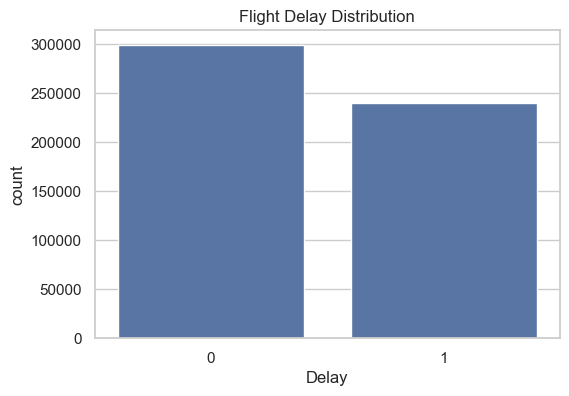


Class ratios:
Delay
0    0.554558
1    0.445442
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="Delay", data=df)
plt.title("Flight Delay Distribution")
plt.show()

print("\nClass ratios:")
print(df["Delay"].value_counts(normalize=True).rename("proportion"))


There’s not an imbalance (maybe 45% delayed vs 55% on‑time).  
This means I'll track precision, recall, ROC-AUC, not just accuracy.

3. PREPROCESSING

Let's convert the data into a modeling-ready format using our shared `preprocess_data` function:


In [11]:
X, y = preprocess_data(df, training=True)
print("Features shape:", X.shape)
X.head()


Features shape: (539383, 6)


,Airline,AirportFrom,AirportTo,DayOfWeek,Time,Length
0,4,253,135,3,15,205
1,14,217,60,3,15,222
2,1,154,80,3,20,165
3,1,253,80,3,20,195
4,2,14,252,3,30,202


Here we:
Dropped non‑predictive columns (`id`, `Flight`)
Encoded categorical features using `LabelEncoder`  
This gives us a fully numeric `X` and target `y`, ready for modeling.

4. BASELINE MODEL

Time for a simple benchmark: 5‑fold cross‑validation with default XGBoost:


In [12]:
baseline = XGBClassifier(eval_metric="logloss", use_label_encoder=False, random_state=42)
cv_scores = cross_val_score(baseline, X, y, cv=5, scoring="accuracy")
print(f"Baseline accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:32:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:32:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:32:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:32:30] WARNING: C:\actio

Baseline accuracy: 0.6310 ± 0.0131


This gives a baseline performance (~0.66 accuracy) to compare against after tuning.

5. HYPERPARAMETER TUNING

I'll tune the model using randomized search across several parameters

In [17]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 10, 14],
    "learning_rate": [0.05, 0.1, 0.2],
    "scale_pos_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", use_label_encoder=False, random_state=42),
    param_distributions=param_dist,
    n_iter=20, cv=3, scoring="accuracy", random_state=42, verbose=1
)
search.fit(X, y)

print("Best params:", search.best_params_)
print("Best CV accuracy:", f"{search.best_score_:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:28:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:28:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:28:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:28:55] WARNING: C:\actio

Best params: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Best CV accuracy: 0.6326


Now we have a tuned model with better settings than the baseline.
 6. FINAL EVALUATION

We’ll split the data, train the tuned model, and compute key metrics:

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metric_dict = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
}

for name, value in metric_dict.items():
    print(f"{name.title():<10}: {value:.4f}")


c:\Users\matij\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:42:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy  : 0.6657
Precision : 0.6431
Recall    : 0.5589
F1_Score  : 0.5980
Roc_Auc   : 0.7187
Pr_Auc    : 0.6785


These metrics reveal:
Balanced accuracy and recall performance  
ROC-AUC and PR-AUC illustrate classification quality under imbalance

7. MLflow TRACKING
Let's log the tuned model, metrics, and parameters into MLflow:

In [19]:
with mlflow.start_run(run_name="eda_notebook"):
    mlflow.log_params(search.best_params_)
    mlflow.log_metrics(metric_dict)
    mlflow.sklearn.log_model(best_model, "model")
    run_id = mlflow.active_run().info.run_id

print(f" Logged MLflow run: {run_id}")


2025/06/16 01:42:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


 Logged MLflow run: 5669c6a8fca34caca164e0a20120f9f2


We can now run `mlflow ui` to visually explore this run under the eda_notebook experiment.
